In [1]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import pandas as pd

c:\Users\Prathik Matthai\Downloads\Post-Hoc-Explainability\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%pip install lime


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.9 MB 2.4 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/12.9 MB 3.0 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/12.9 MB 3.1 MB/s eta 0:00:04
   ------- -------------------------------- 2.4/12.9 MB 3.3 MB/s eta 0:00:04
   --------- ------------------------------ 3.1/12.9 MB 2.8 MB/s eta 0:00:04
   ---------- ----------------------------- 3.4/12.9 MB 2.9 MB/s eta 0:00:04
   ----------- ---------------------------- 3.7/12.9 MB 2.6 MB/s eta 0:00:04
   ------------ --------------------------- 3.9/12.9 MB 2.3 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.9 MB 2.1 MB/s eta 0:00:05
  

  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [3]:
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare the data

In [4]:
df = pd.read_csv(r"../data/adult_income.csv")

In [5]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe(include='all'))

# Check target distribution
print(df.columns.tolist())


(1664500, 12)
   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P   ST    PINCP
0  18.0  1.0  18.0  5.0  4720.0  13.0  17.0  21.0  2.0    2.0  1.0   1600.0
1  53.0  5.0  17.0  5.0  3605.0  18.0  16.0  40.0  1.0    1.0  1.0  10000.0
2  41.0  1.0  16.0  5.0  7330.0   1.0  17.0  40.0  1.0    1.0  1.0  24000.0
3  18.0  6.0  18.0  5.0  2722.0   1.0  17.0   2.0  2.0    1.0  1.0    180.0
4  21.0  5.0  19.0  5.0  3870.0  12.0  17.0  50.0  1.0    1.0  1.0  29000.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664500 entries, 0 to 1664499
Data columns (total 12 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   AGEP    1664500 non-null  float64
 1   COW     1664500 non-null  float64
 2   SCHL    1664500 non-null  float64
 3   MAR     1664500 non-null  float64
 4   OCCP    1664500 non-null  float64
 5   POBP    1664500 non-null  float64
 6   RELP    1664500 non-null  float64
 7   WKHP    1664500 non-null  float64
 8   SEX     1664500 non-nu

In [6]:
df = df[df['PINCP'].notna()]  # Drop missing incomes if needed

# Create binary target: 1 if income > 50K, else 0
df['incg50'] = (df['PINCP'] > 50000).astype(int)
target_col = 'incg50'


In [7]:
X = df.drop(columns=['incg50', 'PINCP'])  
y = df['incg50']

# Identify types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include='number').columns.tolist()

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
X_train_np = X_train.values
X_test_np = X_test.values
feature_names = X_train.columns.tolist()
class_names = ['<=50K', '>50K']

In [9]:
explainer = LimeTabularExplainer(
    X_train_np, feature_names=feature_names, class_names=class_names, categorical_features=[X_train.columns.get_loc(col) for col in categorical_cols],
    discretize_continuous=True, mode='classification'
)

In [10]:
instance_idx = 0  # explain the first test instance
instance = X_test_np[instance_idx]

In [16]:

kernel_widths = np.linspace(0.1, 5.0, 20)
best_r2 = -np.inf
best_exp = None
best_sigma = None


In [17]:
# Define and fit the pipeline if not already fitted
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [23]:
from sklearn.metrics import classification_report

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85    210374
           1       0.76      0.72      0.74    122526

    accuracy                           0.81    332900
   macro avg       0.80      0.79      0.79    332900
weighted avg       0.81      0.81      0.81    332900



In [28]:
rf_model = rf_pipeline.named_steps['rf']
print(rf_model)

RandomForestClassifier(random_state=42)


In [30]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Prepare data for LIME
X_train_np = X_train.values
X_test_np = X_test.values
feature_names = X_train.columns.tolist()
class_names = ['<=50K', '>50K']
categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]

# Initialize LIME explainer
explainer = LimeTabularExplainer(X_train_np, feature_names=feature_names, class_names=class_names, categorical_features=categorical_features,
    discretize_continuous=True, mode='classification'
)


In [34]:
# Select a test instance to explain
instance_idx = 0  # You can change this index to explain other instances
instance = X_test_np[instance_idx]

# OPTILIME: Search for best kernel width (sigma) for local fidelity
kernel_widths = np.linspace(0.1, 5.0, 20)
best_r2 = -np.inf
best_exp = None
best_sigma = None



c:\Users\Prathik Matthai\Downloads\Post-Hoc-Explainability\.conda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Prathik Matthai\Downloads\Post-Hoc-Explainability\.conda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Prathik Matthai\Downloads\Post-Hoc-Explainability\.conda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Prathik Matthai\Downloads\Post-Hoc-Explainability\.conda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Prathik Matthai\Downloads\Post-Hoc-Explainability\.cond

Best local fidelity (R^2): 0.4676 with sigma = 0.87
OPTILIME explanation (feature, weight):
[('WKHP > 44.00', 0.1974576715407914), ('AGEP <= 30.00', -0.1797653941561505), ('4200.00 < OCCP <= 5740.00', -0.0860382607513681), ('1.00 < SEX <= 2.00', -0.07289197424825823), ('RELP > 2.00', -0.0569092060977233), ('16.00 < SCHL <= 19.00', -0.04174311967917824), ('1.00 < MAR <= 5.00', -0.021239796280746133), ('RAC1P <= 1.00', 0.01806334293702028), ('12.00 < ST <= 28.00', -0.010082944250410064), ('COW <= 1.00', -0.010063573577848666), ('36.00 < POBP <= 48.00', 0.0030343273839361193)]


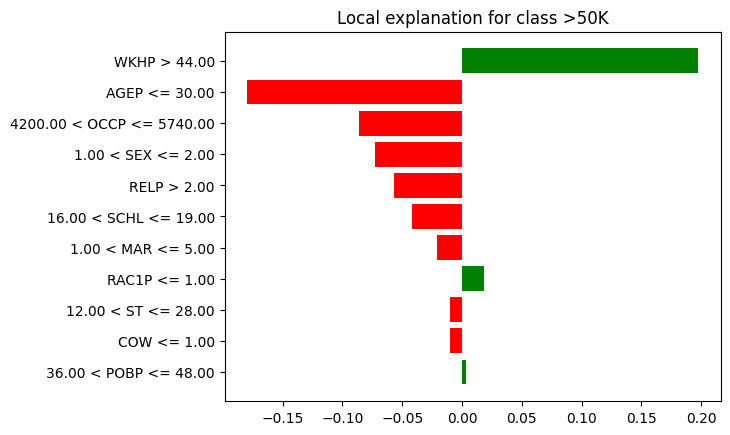

In [ ]:
best_r2 = -np.inf
best_exp = None
best_sigma = None

for sigma in kernel_widths:
    explainer_sigma = LimeTabularExplainer( X_train_np, feature_names=feature_names, class_names=class_names,
        categorical_features=[X_train.columns.get_loc(col) for col in categorical_cols], discretize_continuous=True, mode='classification', kernel_width=sigma
    )
    
    exp = explainer_sigma.explain_instance(instance, rf_pipeline.predict_proba, num_features=len(feature_names))
    r2 = exp.score if hasattr(exp, "score") else None
    if r2 is not None and r2 > best_r2:
        best_r2 = r2
        best_exp = exp
        best_sigma = sigma

if best_exp is not None:
    print(f"Best local fidelity (R^2): {best_r2:.4f} with sigma = {best_sigma:.2f}") 
    print("OPTILIME explanation (feature, weight):")
    print(best_exp.as_list(label=1))
    best_exp.as_pyplot_figure(label=1)
    plt.show()
else:
    print("No valid explanation found.")

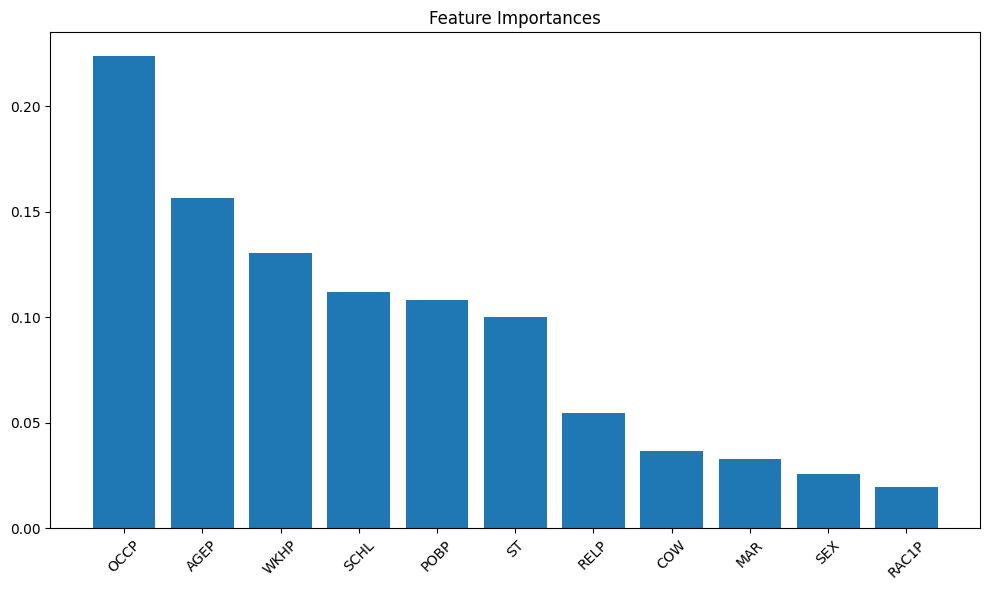

In [40]:
# Visualize feature importances from the Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(feature_names)), importances[indices], align="center")
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()


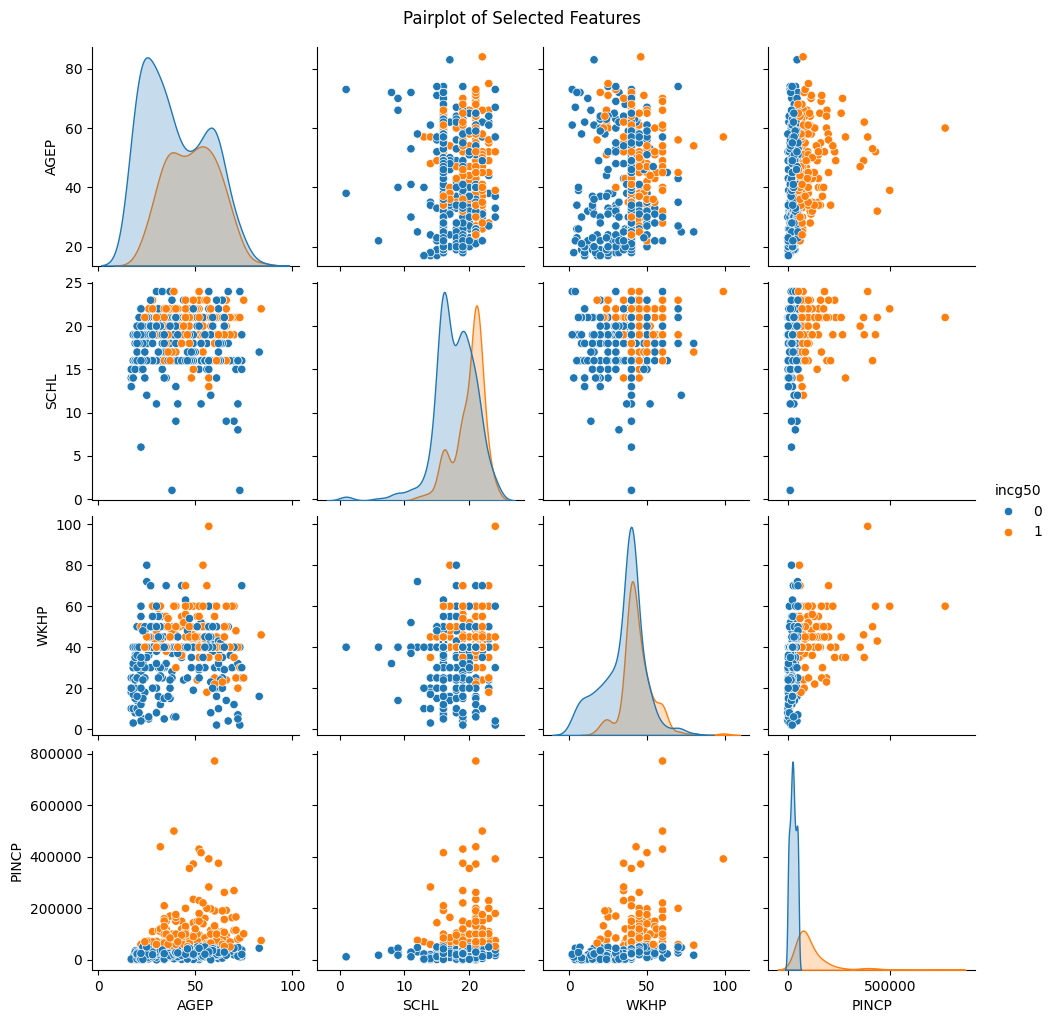

In [42]:
# Visualize a pairplot for a sample of the data
sample_df = df.sample(500, random_state=42)
sns.pairplot(sample_df, vars=['AGEP', 'SCHL', 'WKHP', 'PINCP'], hue='incg50', diag_kind='kde')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()